# Pagoda2.1 CITE-seq Workflow (RNA + protein)

A CITE-seq sample (10x [PBMC 1k protein
v3](https://www.10xgenomics.com/datasets/1-k-pbm-cs-using-3-prime-feature-barcoding-3-standard-3-0-0))
measures each cell by both RNA and a panel of surface-protein antibodies
(ADT). In pagoda2.1 each modality is a **facet** with its own
normalization recipe: RNA uses `plain` (depth-normalize + log1p),
CITE-seq protein uses `clr` (centered log-ratio). Pipeline steps are
generic (the algorithm is a `method=`); cross-modality integration is
`runGraph(method = "wnn")`. The 10x file is in a local folder named
`data`.

## Import

A multimodal 10x HDF5 is split into facets automatically from its
`feature_type` column:

In [ ]:
p2 <- pagoda2::Pagoda2$from10xH5("data/pbmc_1k_protein_v3_filtered_feature_bc_matrix.h5", verbose = FALSE)
sapply(p2$listFacets(), function(f) p2$getFacet(f)$modelType)   # facet -> view model

    RNA     ADT 
"plain"   "clr" 

## QC

In [ ]:
p2$runQC(verbose = FALSE)

## Per-facet reductions

Each facet is reduced on its own: RNA → PCA, ADT → PCA on the CLR view.
Scores are name-keyed (`PCA` for the default RNA facet, `ADT:PCA` for
ADT).

In [ ]:
p2$runVariance(verbose = FALSE)
p2$runReduction(nPcs = 25, verbose = FALSE)
p2$runVariance(facet = "ADT", use.raw.variance = TRUE, verbose = FALSE)
p2$runReduction(facet = "ADT", nPcs = 15, verbose = FALSE)
names(p2$reductions)

[1] "PCA"     "ADT:PCA"

## WNN integration and clustering

`runGraph(method = "wnn")` learns a per-cell weight for each modality
and fuses their neighborhoods into `graphs[["WNN"]]` (with a joint
`reductions[["WNN"]]` and per-cell `cellMeta$wnn_weight_*`). We then
cluster on that graph.

In [ ]:
p2$runGraph(method = "wnn", facets = c("RNA", "ADT"), verbose = FALSE)
p2$runClustering(graph = "WNN", name = "wnn_leiden")

## What each modality resolves

Embed each facet’s own reduction and the joint WNN reduction, then color
all three by the **same** joint clusters. RNA alone and protein alone
each separate some populations but blur others; WNN combines them.

In [ ]:
p2$runEmbedding(reduction = "PCA", name = "umap", verbose = FALSE)        # RNA alone
p2$runEmbedding(reduction = "ADT:PCA", name = "umap", verbose = FALSE)    # protein alone
p2$runEmbedding(reduction = "WNN", name = "umap", verbose = FALSE)        # joint

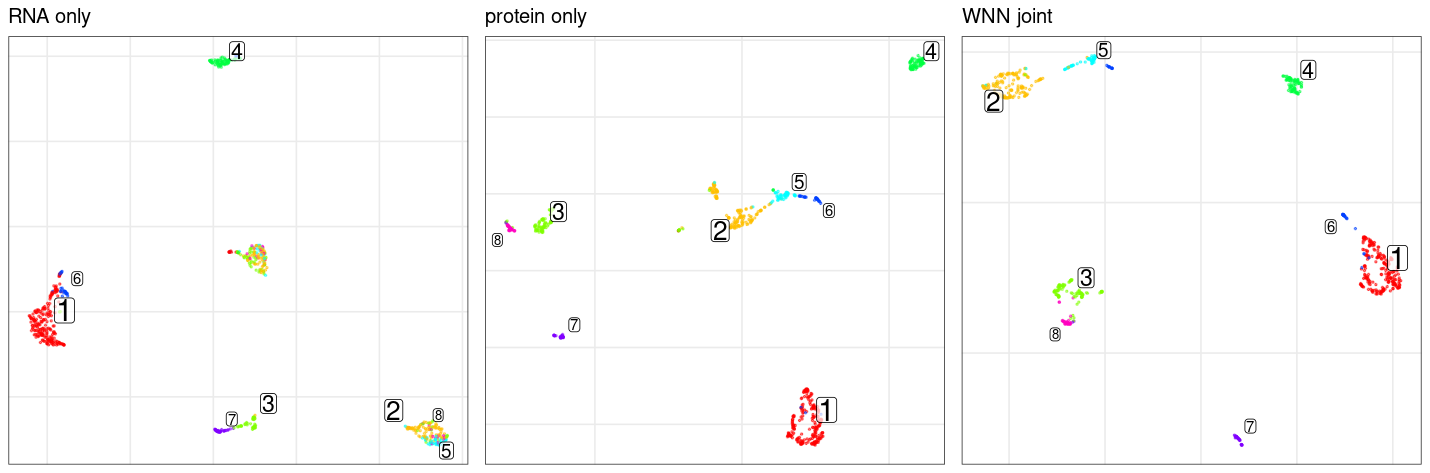

In [ ]:
g_rna <- p2$plotEmbedding(reduction = "PCA", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "RNA only")
g_adt <- p2$plotEmbedding(reduction = "ADT:PCA", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "protein only")
g_wnn <- p2$plotEmbedding(reduction = "WNN", embedding = "umap", grouping = "wnn_leiden", mark.groups = TRUE, size = 0.4, alpha = 0.5, title = "WNN joint")
cowplot::plot_grid(g_rna, g_adt, g_wnn, nrow = 1)

The per-cell ADT weight shows where protein, rather than RNA, drives the
joint structure:

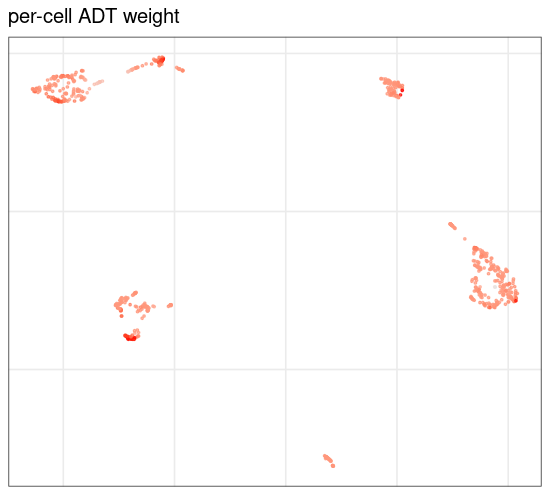

In [ ]:
p2$plotEmbedding(reduction = "WNN", embedding = "umap",
                 colors = stats::setNames(p2$cellMeta$wnn_weight_ADT, rownames(p2$cellMeta)),
                 size = 0.5, alpha = 0.7, title = "per-cell ADT weight")

## Markers

RNA markers per cluster (`runMarkers` on the default RNA facet, then the
dot plot):

In [ ]:
p2$runMarkers(grouping = "wnn_leiden", name = "wnn_markers", verbose = FALSE)

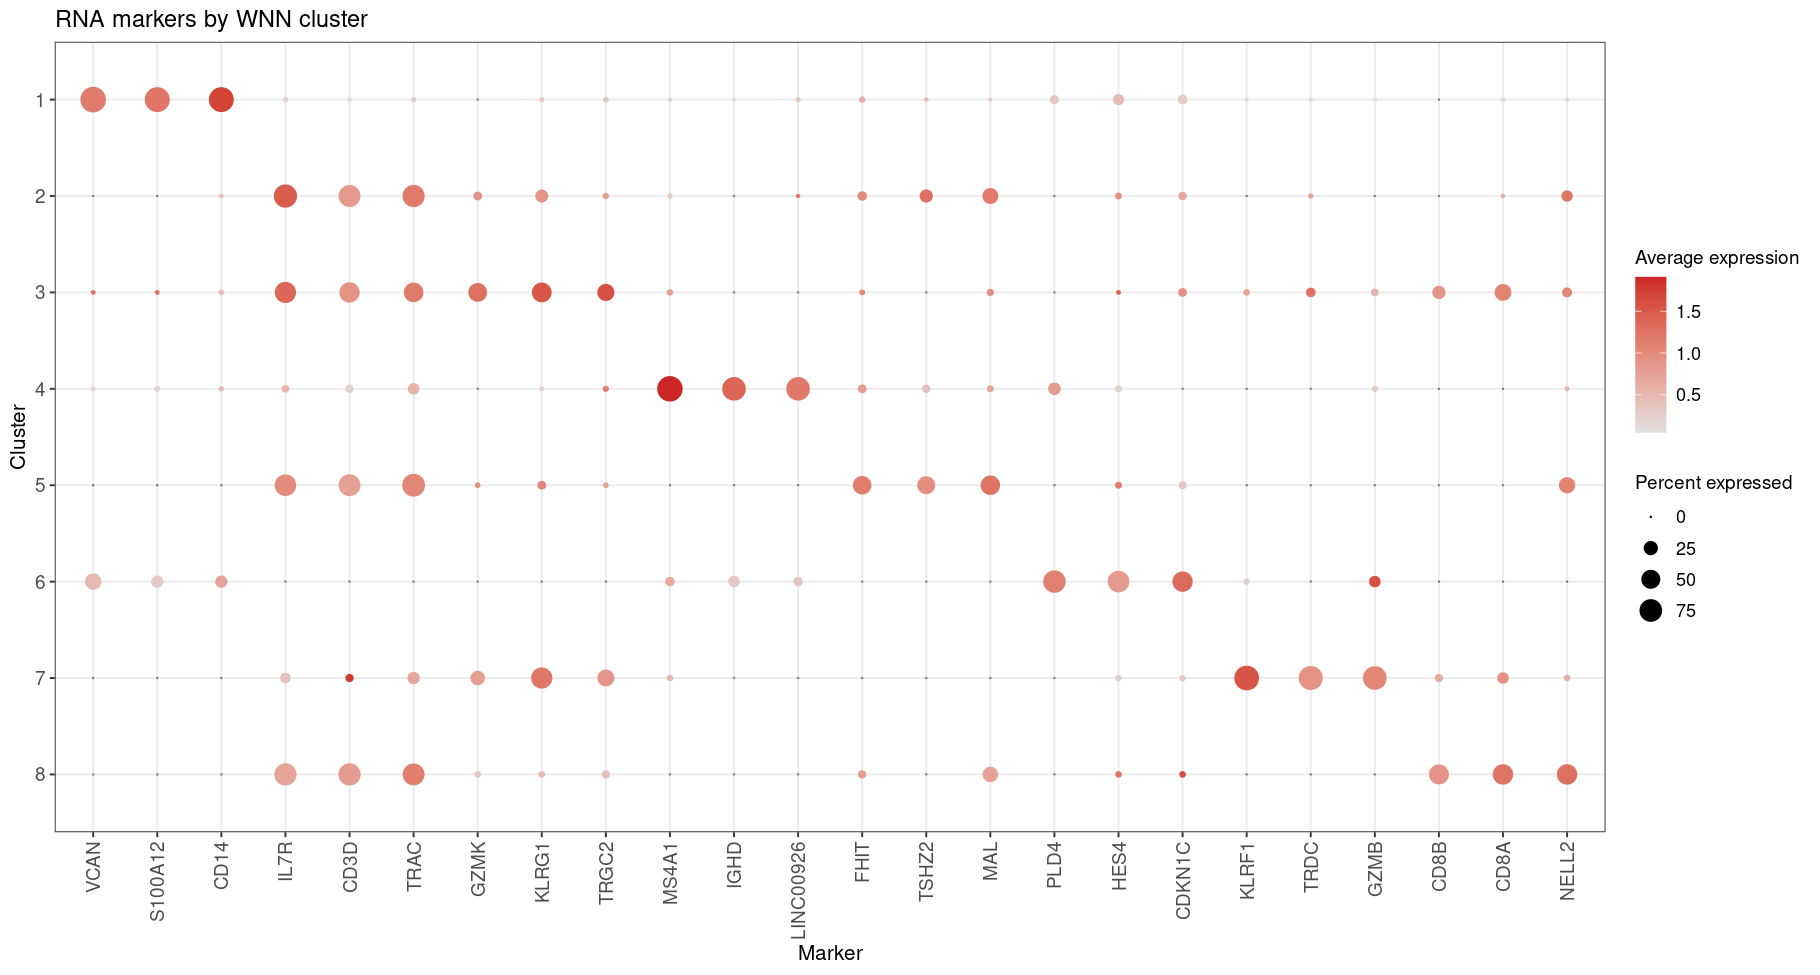

In [ ]:
p2$plotMarkerDotPlot(markers = "wnn_markers", n.genes.per.group = 3, selection = "balanced",
                     order.groups = TRUE, dot.scale = 6) +
  ggplot2::labs(title = "RNA markers by WNN cluster") +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 1, vjust = 0.5))

The protein panel is small and detected in ~every cell, so the clearest
view is the mean CLR per protein across clusters
(`getExpressionBlock(facet = "ADT")` gives the CLR matrix). Surface
markers (CD3/CD4/CD8/CD19/CD14/…) cleanly label the joint clusters:

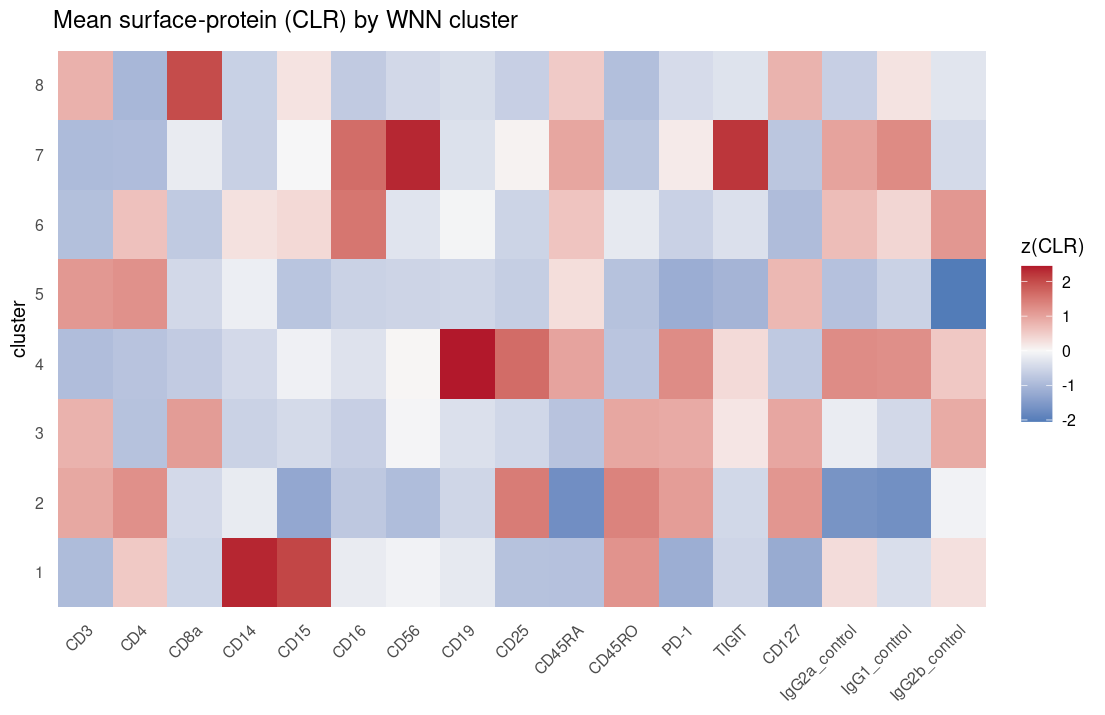

In [ ]:
adt <- as.matrix(p2$getExpressionBlock(facet = "ADT"))                                  # cells x proteins, CLR
prot <- t(sapply(split(rownames(adt), p2$cellMeta[rownames(adt), "wnn_leiden"]),        # mean per cluster
                 function(cells) colMeans(adt[cells, , drop = FALSE])))
colnames(prot) <- sub("_TotalSeqB$", "", colnames(prot))
z <- scale(prot)                                                                        # z-score per protein
df <- data.frame(cluster = rownames(z)[row(z)], protein = factor(colnames(z)[col(z)], colnames(z)), z = c(z))
ggplot2::ggplot(df, ggplot2::aes(protein, cluster, fill = z)) +
  ggplot2::geom_tile() +
  ggplot2::scale_fill_gradient2(low = "#2166ac", mid = "grey97", high = "#b2182b", name = "z(CLR)") +
  ggplot2::theme_minimal(base_size = 11) +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 45, hjust = 1), panel.grid = ggplot2::element_blank()) +
  ggplot2::labs(title = "Mean surface-protein (CLR) by WNN cluster", x = NULL, y = "cluster")

## Next steps

Annotate the WNN clusters from the joint RNA + protein evidence
(`p2$annotateClusters(from = "wnn_leiden", ...)`). Other joint methods
are reduction-level:
`p2$runReduction(facets = c("RNA","ADT"), method = "cca")`. Color the
embedding by any feature from any facet with
`p2$plotEmbedding(gene = "CD3_TotalSeqB", facet = "ADT")`. See the
[single-dataset](pagoda2.1-single-dataset.ipynb) and [ATAC /
multiome](pagoda2.1-multiome.ipynb) notebooks for the other modalities.